WEEK 2 (ASSIGNMENT 1)

In [3]:
# Importing all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

---
## Part A: Dataset Understanding

Q1. Load the dataset and display the first five records

In [4]:
df = pd.read_csv('Dataset 2.csv')
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


Q2. Number of rows and columns in the dataset

In [5]:
rows, columns = df.shape
print('Number of rows:', rows)
print('Number of columns:', columns)

Number of rows: 750
Number of columns: 10


Q3. Display all column names

In [6]:
print('Column names:')
print(df.columns.tolist())

Column names:
['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek', 'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend', 'SubscriptionRenewed']


Q4. Identify numerical and categorical features

In [7]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print('Numerical Features:', numerical_features)
print('Categorical Features:', categorical_features)

Numerical Features: ['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend']
Categorical Features: ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']


Q5. Check whether the dataset contains missing values

In [8]:
print('Missing values in each column:')
print(df.isnull().sum())
print()
print('Total missing values:', df.isnull().sum().sum())

Missing values in each column:
UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64

Total missing values: 0


---
## Part B: Exploratory Data Analysis

Q6. Calculate the average age of users

In [9]:
avg_age = df['Age'].mean()
print('Average age of users:', round(avg_age, 2))

Average age of users: 41.82


Q7. Determine the average watch hours per week

In [10]:
avg_watch = df['WatchHoursPerWeek'].mean()
print('Average watch hours per week:', round(avg_watch, 2))

Average watch hours per week: 14.24


Q8. Find the average monthly spending of users

In [11]:
avg_spend = df['MonthlySpend'].mean()
print('Average monthly spending: ₹', round(avg_spend, 2))

Average monthly spending: ₹ 689.91


Q9. Count the number of users in each subscription category

Users in each subscription category:
SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64


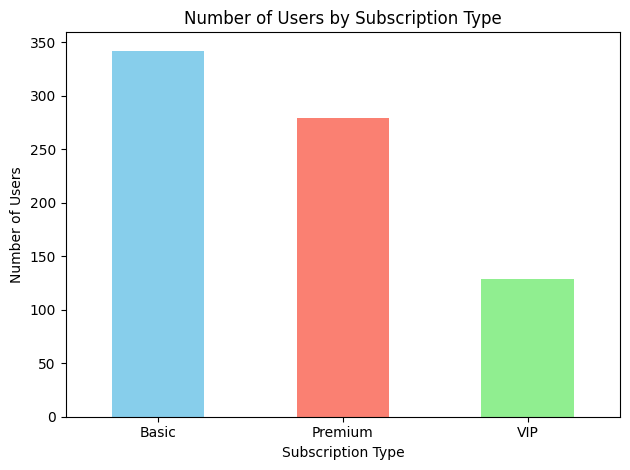

In [12]:
subscription_counts = df['SubscriptionType'].value_counts()
print('Users in each subscription category:')
print(subscription_counts)

# Bar chart
subscription_counts.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Number of Users by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Number of Users')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Q10. Determine the percentage of users who renewed their subscriptions

In [13]:
renewed = df['SubscriptionRenewed'].value_counts()
renewed_percent = (renewed['Yes'] / len(df)) * 100
print('Percentage of users who renewed:', round(renewed_percent, 2), '%')
print('Percentage who did not renew:', round(100 - renewed_percent, 2), '%')

Percentage of users who renewed: 46.27 %
Percentage who did not renew: 53.73 %


---
## Part C: Data Preparation

Q11. Convert categorical features into numerical form

In [14]:
df_encoded = df.copy()

le = LabelEncoder()

df_encoded['Gender'] = le.fit_transform(df_encoded['Gender'])
df_encoded['SubscriptionType'] = le.fit_transform(df_encoded['SubscriptionType'])
df_encoded['FavoriteGenre'] = le.fit_transform(df_encoded['FavoriteGenre'])
df_encoded['SubscriptionRenewed'] = le.fit_transform(df_encoded['SubscriptionRenewed'])

print('Dataset after encoding:')
df_encoded.head()

Dataset after encoding:


,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,0,0,23,5,1,13,353,0
1,1002,55,1,0,9,4,2,14,317,1
2,1003,49,1,0,8,3,1,16,309,0
3,1004,39,0,1,19,5,2,45,833,1
4,1005,38,0,1,23,5,5,24,804,1


Q12. Define feature set (X) and target variable (y) for subscription renewal prediction

In [15]:
X = df_encoded.drop(columns=['UserID', 'SubscriptionRenewed', 'MonthlySpend'])
y = df_encoded['SubscriptionRenewed']

print('Feature set (X) columns:', X.columns.tolist())
print('Target variable (y): SubscriptionRenewed')

Feature set (X) columns: ['Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek', 'DevicesUsed', 'FavoriteGenre', 'AdClicks']
Target variable (y): SubscriptionRenewed


Q13. Split the dataset into training and testing sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set size:', X_train.shape[0])
print('Testing set size:', X_test.shape[0])

Training set size: 600
Testing set size: 150


---
## Part D: Decision Tree Classification

 Q14. Train a Decision Tree model

In [17]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print('Decision Tree model trained successfully!')

Decision Tree model trained successfully!


Q15. Evaluate the model using accuracy

In [18]:
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print('Decision Tree Accuracy:', round(dt_accuracy * 100, 2), '%')

Decision Tree Accuracy: 55.33 %


Q16. Generate and interpret the confusion matrix

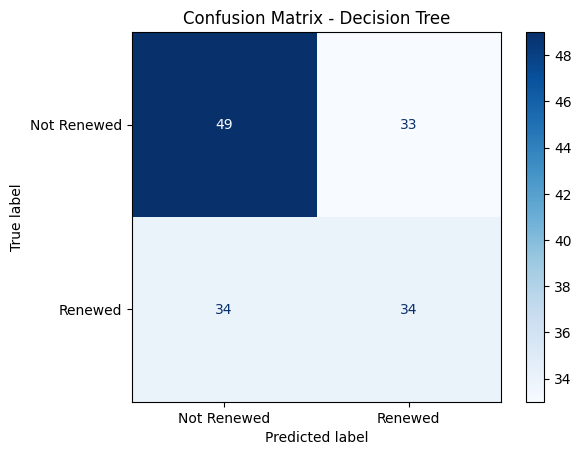

Confusion Matrix:
[[49 33]
 [34 34]]

Interpretation:
True Negatives (correctly predicted Not Renewed): 49
False Positives (wrongly predicted as Renewed): 33
False Negatives (wrongly predicted as Not Renewed): 34
True Positives (correctly predicted Renewed): 34


In [19]:
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Renewed', 'Renewed'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

print('Confusion Matrix:')
print(cm)
print()
print('Interpretation:')
print('True Negatives (correctly predicted Not Renewed):', cm[0][0])
print('False Positives (wrongly predicted as Renewed):', cm[0][1])
print('False Negatives (wrongly predicted as Not Renewed):', cm[1][0])
print('True Positives (correctly predicted Renewed):', cm[1][1])

---
## Part E: K-Nearest Neighbors (KNN)

Q17. Train a KNN classifier with K = 5

In [20]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

print('KNN model trained with K = 5')

KNN model trained with K = 5


Q18. Compare the accuracy of KNN with the Decision Tree model

In [21]:
y_pred_knn = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print('KNN Accuracy:', round(knn_accuracy * 100, 2), '%')
print('Decision Tree Accuracy:', round(dt_accuracy * 100, 2), '%')
print()
if dt_accuracy > knn_accuracy:
    print('Decision Tree performed better than KNN for this dataset.')
elif knn_accuracy > dt_accuracy:
    print('KNN performed better than Decision Tree for this dataset.')
else:
    print('Both models performed equally.')

KNN Accuracy: 58.67 %
Decision Tree Accuracy: 55.33 %

KNN performed better than Decision Tree for this dataset.


---
## Part F: Linear Regression

Q19. Train a Linear Regression model to predict monthly spending

In [22]:
X_reg = df_encoded.drop(columns=['UserID', 'MonthlySpend', 'SubscriptionRenewed'])
y_reg = df_encoded['MonthlySpend']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_reg_train, y_reg_train)

print('Linear Regression model trained successfully!')

y_pred_lr = lr_model.predict(X_reg_test)

# Show some predictions vs actual
result = pd.DataFrame({'Actual Spend': y_reg_test.values[:10], 'Predicted Spend': y_pred_lr[:10].round(2)})
print()
print('Sample predictions vs actual values:')
print(result.to_string(index=False))

Linear Regression model trained successfully!

Sample predictions vs actual values:
 Actual Spend  Predicted Spend
          853           838.55
          314           375.01
          747           802.15
          384           326.06
          467           356.22
         1441          1319.48
          743           816.56
          711           850.32
         1379          1287.72
         1311          1316.33


Q20. Predict the monthly spending for a new user

 New user details:\
Age=30, Gender=Female(0), SubscriptionType=Premium(1), WatchHoursPerWeek=15,\
DevicesUsed=3, FavoriteGenre=Drama(1), AdClicks=20

In [23]:
new_user = pd.DataFrame([{
    'Age': 30,
    'Gender': 0,
    'SubscriptionType': 1,
    'WatchHoursPerWeek': 15,
    'DevicesUsed': 3,
    'FavoriteGenre': 1,
    'AdClicks': 20
}])

predicted_spend = lr_model.predict(new_user)
print('Predicted Monthly Spend for the new user: ₹', round(predicted_spend[0], 2))
print()
print('Interpretation: Based on the user profile (age 30, Premium subscriber,',
      '15 hours of watch time per week, 3 devices, 20 ad clicks),',
      'the model predicts a monthly spending of approximately ₹', round(predicted_spend[0], 2))

Predicted Monthly Spend for the new user: ₹ 832.71

Interpretation: Based on the user profile (age 30, Premium subscriber, 15 hours of watch time per week, 3 devices, 20 ad clicks), the model predicts a monthly spending of approximately ₹ 832.71


---
## Business Reflection Questions

**1. Which factors appear to influence subscription renewal the most?**

From the dataset, features like `WatchHoursPerWeek`, `MonthlySpend`, `SubscriptionType`, and `AdClicks` are likely the strongest influencers. Users who watch more hours and spend more per month tend to be more engaged, making them more likely to renew. The subscription tier also plays a role — VIP/Premium users may have more to lose by cancelling.

**2. Why is subscription renewal a classification problem?**

Because the output (target variable `SubscriptionRenewed`) is a category — either **Yes** or **No**. Classification algorithms are used when we need to predict which group or class a data point belongs to, rather than predicting a continuous number.

**3. Why is monthly spending a regression problem?**

Because `MonthlySpend` is a continuous numerical value (e.g., ₹317, ₹804). Regression is used when the target variable can take any value within a range, rather than a fixed set of categories.

**4. Which algorithm performed better for renewal prediction?**

The accuracy values printed above will tell us directly. In general, Decision Tree can perform well on structured tabular data but may overfit, while KNN depends heavily on the scale of features. Based on the results in this notebook, the better-performing model is identified in Q18.

**5. How could the platform use these predictions to improve customer retention?**

Netflix could use the renewal prediction model to identify users who are **unlikely to renew** in advance, and then target them with personalised offers, discounts, or content recommendations. The spending prediction model can help with pricing strategy — understanding what kind of users spend more helps in designing subscription plans. Together, these models enable proactive retention strategies rather than reactive ones.